In [ ]:
import os
import pickle
import networkx as nx
import matplotlib.pyplot as plt

# import the karstnet version on the ERC-Karst/Karstnet-ERC github:
# clone repository, navigate to the repository with command line,
# pip install .    (the . is part of the command)
import karstnet as kn

## Load the data

In [2]:
#load graph
cavename = 'GouffreDejaVu'

list_folder = os.listdir('../data')
#find automatically the number associated with the cavename
number = [item.split('_')[0] for item in list_folder if cavename in item][0]
path_to_yaml = f'../data/{number}_{cavename}/clean_data/{cavename}.yaml'

G = kn.io_func.networkx_from_yaml(path_to_yaml,add_edge_attr='all',add_node_attr='all')


## Access the metadata

In [3]:
#some metadata are attached to the graph. you can access them with:
number = G.graph['number']
status = G.graph['status']

#print all the metadata dictionnary
G.graph

KeyError: 'number'

## Visualizing the data

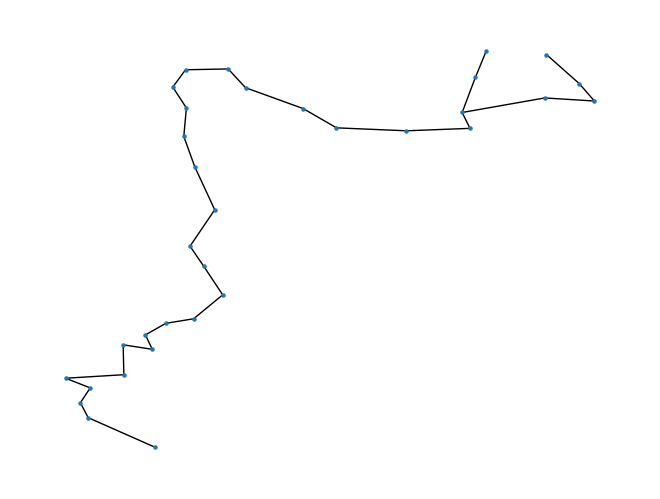

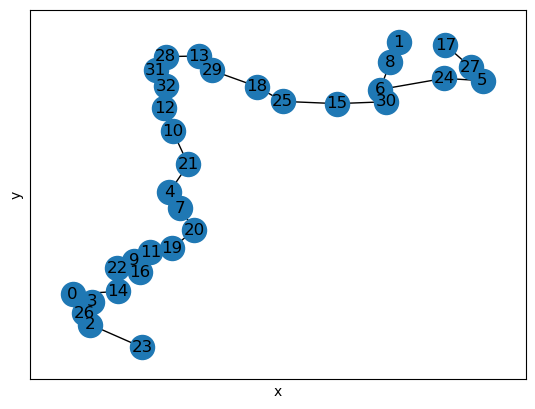

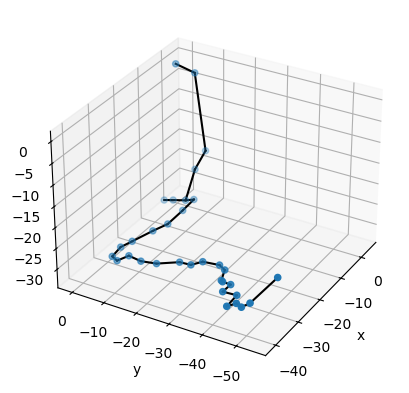

In [4]:
#example on how to plot the graph using the pos2d function from KNtools toolbox
#this function creates a dictionnary of x,y position
plt.figure()
pos2d = kn.utils.get_pos2d(G)
nx.draw(G,pos=pos2d,node_size=5)

#examples on how to use the plotting function from Karstnet
# those plot can be costumized
plt.figure()
kn.view.plot_graph2d(G)

plt.figure()
kn.view.plot_graph3d(G)

## Access graph attributes

this is the list of attributes attached to the nodes: ['splays', 'fulladdress', 'csdim', 'idsql', 'pos']
this is the list of attributes attached to the edges: []
Cross-sectional dimension attached to the nodes: {17: [2.31, 1.1], 27: [2.27, 2.4], 24: [10.25, 6.38], 6: [4.01, 4.01], 1: [5.53, 1.15], 15: [0.6, 1.21], 25: [3.55, 0.82], 18: [2.37, 1.01], 13: [2.34, 1.62], 28: [2.25, 0.97], 7: [2.94, 3.41], 19: [6.37, 3.97], 11: [1.08, 1.18], 22: [0.98, 5.6]}


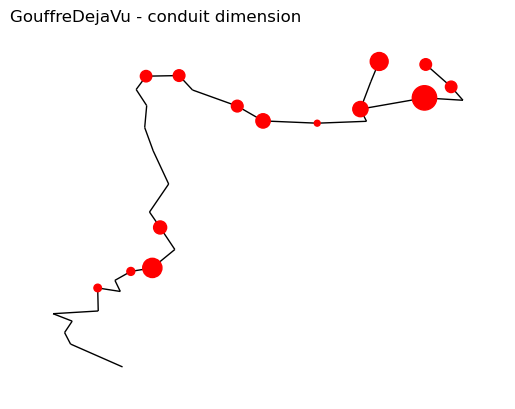

In [20]:
#If you want to know which attributes are attached to the graph:
# get a list of all the dictionnaries that exists:
print(f'this is the list of attributes attached to the nodes: {kn.utils.get_node_attribute_names(G)}')
print(f'this is the list of attributes attached to the edges: {kn.utils.get_edge_attribute_names(G)}')

#example to access the attributes:
csdim_dict = nx.get_node_attributes(G,'csdim') #dictionnary of list [width,height]
print(f'Cross-sectional dimension attached to the nodes: {csdim_dict}')

# get the dictionnary of coordinates (x,y,z or x,y)
# pos3d = nx.get_node_attributes(G,'pos')
pos3d = kn.utils.get_pos3d(G) # this function fill set z to 0 in the case the there is only x,y coordinates
pos2d = kn.utils.get_pos2d(G) # this is usefull for plotting 2D

#exemple PLOT WITH WEIGHTED NODE GEOMETRY
node_sizes = []
labels = {}
for n in G.nodes:
    if G.nodes('csdim')[n] is not None:
        node_sizes.append( nx.get_node_attributes(G,'csdim')[n][0]*30 )
    else:
        node_sizes.append( 0.0 )

plt.figure()
ax = plt.gca()
ax.set_title(f'{cavename} - conduit dimension', loc='left',ha='left', wrap=True )
nx.draw(G,kn.utils.get_pos2d(G),node_size=node_sizes ,with_labels=False, node_color='red', ax=ax)

Therion Import -- Importing all links (including splays) -- 0.011600255966186523s
Therion Import -- Importing all nodes data (including splays) -- 0.013037443161010742s
Therion Import -- Create initial graph with all the data points (including splays) -- 0.01574230194091797s
Therion Import -- Combine Stations with identical x,y,z -- 0.019878387451171875s
0/33 unique positions
Therion Import -- Rename nodes -- 0.020482301712036133s
0/33 nodes to rename
Therion Import -- concatenate old ic in a dictionnary -- 0.020536184310913086s
Therion Import -- Relabel nodes -- 0.02056145668029785s
Therion Import -- remove self links -- 0.02080512046813965s
Therion Import --add dictionnaries to graph -- 0.020850419998168945s
Therion Import -- add splays -- 0.02086806297302246s
Therion Import -- add fulladdress -- 0.02163243293762207s
Therion Import -- add flags
Therion Import -- add sql ids -- 0.025957345962524414s
Therion Import -- remove isolated nodes -- 0.026056289672851562s

This network contain


- geometry
- splays

- flag / use only portion of the graph

- store attributes / save graph

